# ZOIDBERG2.0 - Step 3: Baseline Modeling & Cross-Validation

**Project:** Medical Imaging / Computer Aided Diagnosis - Pneumonia Detection  
**Author:** ML Architecture Team  
**Date:** January 2026  

---

## Objectives

1. **Load Preprocessed Data:**
   - Load PCA-transformed features from Step 2
   - Verify data integrity

2. **Implement Baseline Models:**
   - Logistic Regression
   - Support Vector Machine (SVM)
   - Random Forest
   - Gradient Boosting

3. **Training Strategies:**
   - Train-test split (80/20)
   - 5-fold cross-validation
   - Compare both approaches

4. **Evaluation Metrics:**
   - **ROC-AUC** (primary metric)
   - Precision, Recall, F1-Score
   - Confusion matrices
   - ROC curves

5. **Feature Importance:**
   - Analyze which features contribute most
   - Visualize feature importance

6. **Model Selection:**
   - Compare all models
   - Select best baseline model
   - Save trained models

---

In [1]:
# Import Required Libraries
import os
import sys
import warnings
from pathlib import Path
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import yaml

# Scikit-learn models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-learn utilities
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score
)

# Imbalanced-learn for handling class imbalance
from imblearn.over_sampling import SMOTE
from collections import Counter

import joblib

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Add src to path
project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

# Import custom modules
from utils.helpers import set_seed, save_model, load_model, Logger

print("✓ Libraries imported successfully")
print(f"✓ Project root: {project_root}")

✓ Libraries imported successfully
✓ Project root: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19


In [2]:
# Load Configuration
config_path = project_root / 'config' / 'config.yaml'

with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Set random seed for reproducibility
set_seed(config['reproducibility']['seed'])

print("✓ Configuration loaded")
print(f"\nProject: {config['project']['name']} v{config['project']['version']}")
print(f"Random Seed: {config['reproducibility']['seed']}")
print(f"CV Folds: {config['data_strategy']['cv_folds']}")

✓ Random seed set to 42
✓ Configuration loaded

Project: ZOIDBERG2.0 v2.0.0
Random Seed: 42
CV Folds: 5


In [3]:
# Initialize Logger
log_path = project_root / config['logging']['log_file']
logger = Logger(log_path)

logger.info("="*60)
logger.info("STEP 3: BASELINE MODELING & CROSS-VALIDATION")
logger.info("="*60)

[INFO] ============================================================
[INFO] STEP 3: BASELINE MODELING & CROSS-VALIDATION
[INFO] ============================================================


---
## 1. Load Preprocessed Data

Load the PCA-transformed features and labels from Step 2.

In [6]:
# Load preprocessed data
processed_dir = project_root / 'data' / 'processed'

print("Loading preprocessed data...\n")

# Load train-test split data
X_train = np.load(processed_dir / 'X_train.npy')
X_test = np.load(processed_dir / 'X_test.npy')
y_train = np.load(processed_dir / 'y_train.npy')
y_test = np.load(processed_dir / 'y_test.npy')

print("Train-Test Split:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape} - {np.unique(y_train, return_counts=True)}")
print(f"  y_test:  {y_test.shape} - {np.unique(y_test, return_counts=True)}")

# Load full data for cross-validation
X_combined_pca = np.load(processed_dir / 'X_combined_pca.npy')
y_combined = np.load(processed_dir / 'y_combined.npy')

print(f"\nCombined Data (for CV):")
print(f"  X_combined: {X_combined_pca.shape}")
print(f"  y_combined: {y_combined.shape} - {np.unique(y_combined, return_counts=True)}")

# Load Dataset3 (reserved for hyperparameter tuning)
X_dataset3_pca = np.load(processed_dir / 'X_dataset3_pca.npy')
y_dataset3 = np.load(processed_dir / 'y_dataset3.npy')

print(f"\nDataset3 (Reserved for Tuning):")
print(f"  X_dataset3: {X_dataset3_pca.shape}")
print(f"  y_dataset3: {y_dataset3.shape} - {np.unique(y_dataset3, return_counts=True)}")

# Check label types and encode if necessary
print(f"\nLabel Type Check:")
print(f"  y_train dtype: {y_train.dtype}")
print(f"  y_train sample: {y_train[:5]}")

from sklearn.preprocessing import LabelEncoder

label_encoder = None
label_mapping = None

if y_train.dtype.kind in ['U', 'S', 'O']:  # String labels
    print("\n⚠️  String labels detected. Encoding to numeric...")
    
    label_encoder = LabelEncoder()
    
    # Fit on all labels for consistency
    all_labels = np.concatenate([y_train, y_test, y_combined, y_dataset3])
    label_encoder.fit(all_labels)
    
    # Transform all label sets
    y_train = label_encoder.transform(y_train)
    y_test = label_encoder.transform(y_test)
    y_combined = label_encoder.transform(y_combined)
    y_dataset3 = label_encoder.transform(y_dataset3)
    
    label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
    class_names = list(label_encoder.classes_)
    
    print(f"  Label mapping: {label_mapping}")
    
    # Save label encoder
    label_encoder_path = project_root / 'models' / 'saved_models' / 'label_encoder.pkl'
    label_encoder_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(label_encoder, label_encoder_path)
    print(f"  ✓ Label encoder saved to: {label_encoder_path}")

else:
    print("  ✓ Labels are already numeric")
    
    if class_names_from_metadata:
        class_names = class_names_from_metadata
        label_mapping = {cls: idx for idx, cls in enumerate(class_names)}
    else:
        unique_numeric_labels = sorted(np.unique(y_train))
        class_names = [f"Class {i}" for i in unique_numeric_labels]
        label_mapping = {name: idx for idx, name in enumerate(class_names)}

num_classes = len(np.unique(y_train))

print(f"\nFinal Label Distribution:")
print(f"  y_train: {np.unique(y_train, return_counts=True)}")
print(f"  y_test:  {np.unique(y_test, return_counts=True)}")
print(f"\nResolved class names: {class_names}")
print(f"Number of classes: {num_classes}")

# Load preprocessing metadata
with open(processed_dir / 'preprocessing_metadata.json', 'r', encoding='utf-8') as f:
    preprocessing_meta = json.load(f)

print(f"\nPreprocessing Info:")
print(f"  PCA Components: {preprocessing_meta['pca_components']}")
print(f"  Feature Method: {preprocessing_meta['feature_method']}")
print(f"  Random Seed: {preprocessing_meta['random_seed']}")
# Load class information if available
class_info_path = processed_dir / 'class_info.json'
if class_info_path.exists():
    with open(class_info_path, 'r', encoding='utf-8') as f:
        class_info = json.load(f)
    
    class_names_from_metadata = class_info.get('class_names', [])
    classification_mode = class_info.get('classification_mode', 'unknown')
else:
    class_info = {}
    class_names_from_metadata = []
    classification_mode = preprocessing_meta.get('classification_mode', 'unknown')

print(f"\nClassification Info:")
print(f"  Mode: {classification_mode}")
print(f"  Classes from metadata: {class_names_from_metadata}")

logger.info(f"Loaded data: Train={X_train.shape}, Test={X_test.shape}, CV={X_combined_pca.shape}")
logger.info(f"Labels encoded: {y_train.dtype}")

Loading preprocessed data...

Train-Test Split:
  X_train: (4185, 792)
  X_test:  (1047, 792)
  y_train: (4185,) - (array(['BACTERIA', 'NORMAL', 'VIRUS'], dtype='<U8'), array([2030, 1079, 1076]))
  y_test:  (1047,) - (array(['BACTERIA', 'NORMAL', 'VIRUS'], dtype='<U8'), array([508, 270, 269]))

Combined Data (for CV):
  X_combined: (5232, 792)
  y_combined: (5232,) - (array(['BACTERIA', 'NORMAL', 'VIRUS'], dtype='<U8'), array([2538, 1349, 1345]))

Dataset3 (Reserved for Tuning):
  X_dataset3: (624, 792)
  y_dataset3: (624,) - (array(['BACTERIA', 'NORMAL', 'VIRUS'], dtype='<U8'), array([242, 234, 148]))

Label Type Check:
  y_train dtype: <U8
  y_train sample: ['NORMAL' 'NORMAL' 'BACTERIA' 'BACTERIA' 'VIRUS']

⚠️  String labels detected. Encoding to numeric...
  Label mapping: {np.str_('BACTERIA'): np.int64(0), np.str_('NORMAL'): np.int64(1), np.str_('VIRUS'): np.int64(2)}
  ✓ Label encoder saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\models\saved_mode

In [7]:
from sklearn.preprocessing import label_binarize

def get_average_type(num_classes):
    """
    Choose averaging strategy for multiclass metrics.
    """
    return 'binary' if num_classes == 2 else 'macro'

def compute_multiclass_roc_auc(y_true, y_score, num_classes):
    """
    Compute ROC-AUC for binary or multiclass classification.
    """
    if num_classes == 2:
        if y_score.ndim == 2:
            return roc_auc_score(y_true, y_score[:, 1])
        return roc_auc_score(y_true, y_score)
    
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    return roc_auc_score(y_true_bin, y_score, multi_class='ovr', average='macro')

def format_class_distribution(y, class_names):
    unique, counts = np.unique(y, return_counts=True)
    summary = dict(zip(unique, counts))
    lines = []
    for idx, cls in enumerate(class_names):
        lines.append(f"  {cls}: {summary.get(idx, 0)}")
    return "\n".join(lines)

---
## 2. Define Baseline Models

Configure multiple baseline ML algorithms with appropriate hyperparameters.

In [8]:
def get_baseline_models():
    """
    Define baseline models with initial hyperparameters.
    
    Returns:
        dict: Dictionary of model name to (model, description)
    """
    random_state = config['reproducibility']['seed']
    
    models = {
        'Logistic Regression': (
            LogisticRegression(
                random_state=random_state,
                max_iter=1000,
                class_weight='balanced',  # Handle class imbalance
                solver='lbfgs',
                n_jobs=-1
            ),
            "Linear model with L2 regularization"
        ),
        
        'SVM (RBF)': (
            SVC(
                random_state=random_state,
                kernel='rbf',
                class_weight='balanced',
                probability=True,  # Enable probability estimates for ROC-AUC
                gamma='scale',
                C=1.0
            ),
            "Support Vector Machine with RBF kernel"
        ),
        
        'Random Forest': (
            RandomForestClassifier(
                random_state=random_state,
                n_estimators=100,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight='balanced',
                n_jobs=-1
            ),
            "Ensemble of decision trees"
        ),
        
        'Gradient Boosting': (
            GradientBoostingClassifier(
                random_state=random_state,
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                subsample=0.8
            ),
            "Sequential ensemble boosting"
        )
    }
    
    return models


# Get models
baseline_models = get_baseline_models()

print("\n" + "="*60)
print("BASELINE MODELS")
print("="*60)
for name, (model, desc) in baseline_models.items():
    print(f"\n{name}:")
    print(f"  Description: {desc}")
    print(f"  Type: {type(model).__name__}")

logger.info(f"Initialized {len(baseline_models)} baseline models")


BASELINE MODELS

Logistic Regression:
  Description: Linear model with L2 regularization
  Type: LogisticRegression

SVM (RBF):
  Description: Support Vector Machine with RBF kernel
  Type: SVC

Random Forest:
  Description: Ensemble of decision trees
  Type: RandomForestClassifier

Gradient Boosting:
  Description: Sequential ensemble boosting
  Type: GradientBoostingClassifier
[INFO] Initialized 4 baseline models


---
## 3. Train-Test Split Evaluation

Train and evaluate models using train-test split strategy.

In [ ]:
def evaluate_model_train_test(model, X_train, y_train, X_test, y_test, model_name, class_names):
    """
    Train and evaluate a model using train-test split.
    
    Supports both binary and multiclass classification.
    """
    num_classes = len(class_names)
    average_type = get_average_type(num_classes)
    
    # Train model
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predictions
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)
    else:
        # Fallback: create one-hot style probabilities from predictions
        y_pred_proba = np.eye(num_classes)[y_pred]
    
    # Metrics
    roc_auc = compute_multiclass_roc_auc(y_test, y_pred_proba, num_classes)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average=average_type, zero_division=0
    )
    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Per-class report
    class_report = classification_report(
        y_test, y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    
    results = {
        'model_name': model_name,
        'roc_auc': roc_auc,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm,
        'classification_report': class_report,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'train_time': train_time,
        'trained_model': model,
        'average_type': average_type
    }
    
    return results

#multiclass
# Train and evaluate all models
print("\n" + "="*60)
print("TRAIN-TEST SPLIT EVALUATION")
print("="*60)

train_test_results = {}

for name, (model, desc) in baseline_models.items():
    print(f"\nTraining {name}...")
    logger.info(f"Training {name} (train-test split)")
    
    results = evaluate_model_train_test(model, X_train, y_train, X_test, y_test, name, class_names)
    train_test_results[name] = results
    
    print(f"  ROC-AUC:   {results['roc_auc']:.4f}")
    print(f"  Averaging: {results['average_type']}")
    print(f"  Accuracy:  {results['accuracy']:.4f}")
    print(f"  Precision: {results['precision']:.4f}")
    print(f"  Recall:    {results['recall']:.4f}")
    print(f"  F1-Score:  {results['f1_score']:.4f}")
    print(f"  Time:      {results['train_time']:.2f}s")
    
    logger.info(f"{name}: ROC-AUC={results['roc_auc']:.4f}, F1={results['f1_score']:.4f}")

print("\n✓ Train-test evaluation complete")


TRAIN-TEST SPLIT EVALUATION

Training Logistic Regression...
[INFO] Training Logistic Regression (train-test split)
  ROC-AUC:   0.8628
  Averaging: macro
  Accuracy:  0.7163
  Precision: 0.7106
  Recall:    0.7225
  F1-Score:  0.7146
  Time:      0.50s
[INFO] Logistic Regression: ROC-AUC=0.8628, F1=0.7146

Training SVM (RBF)...
[INFO] Training SVM (RBF) (train-test split)
  ROC-AUC:   0.8895
  Averaging: macro
  Accuracy:  0.7584
  Precision: 0.7545
  Recall:    0.7455
  F1-Score:  0.7493
  Time:      60.93s
[INFO] SVM (RBF): ROC-AUC=0.8895, F1=0.7493

Training Random Forest...
[INFO] Training Random Forest (train-test split)
  ROC-AUC:   0.8470
  Averaging: macro
  Accuracy:  0.6227
  Precision: 0.7543
  Recall:    0.5176
  F1-Score:  0.5166
  Time:      1.14s
[INFO] Random Forest: ROC-AUC=0.8470, F1=0.5166

Training Gradient Boosting...
[INFO] Training Gradient Boosting (train-test split)
  ROC-AUC:   0.8931
  Averaging: macro
  Accuracy:  0.7584
  Precision: 0.7519
  Recall:    0.

In [12]:
# Create comparison DataFrame
comparison_data = []
for name, results in train_test_results.items():
    comparison_data.append({
        'Model': name,
        'ROC-AUC': results['roc_auc'],
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1_score'],
        'Train Time (s)': results['train_time']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print("\n" + "="*80)
print("TRAIN-TEST SPLIT RESULTS (Sorted by ROC-AUC)")
print(f"  Averaging: {results['average_type']}")
print("="*80)
display(comparison_df.style.format({
    'ROC-AUC': '{:.4f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'Train Time (s)': '{:.2f}'
}).background_gradient(subset=['ROC-AUC'], cmap='YlGn'))


TRAIN-TEST SPLIT RESULTS (Sorted by ROC-AUC)
  Averaging: macro


,Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score,Train Time (s)
3,Gradient Boosting,0.8931,0.7584,0.7519,0.7204,0.7246,175.40
1,SVM (RBF),0.8895,0.7584,0.7545,0.7455,0.7493,60.93
0,Logistic Regression,0.8628,0.7163,0.7106,0.7225,0.7146,0.50
2,Random Forest,0.8470,0.6227,0.7543,0.5176,0.5166,1.14


---
## 4. Cross-Validation Evaluation

Evaluate models using stratified k-fold cross-validation for more robust estimates.

In [13]:
def evaluate_model_cv(model, X, y, model_name, cv_folds=5, num_classes=2):
    """
    Evaluate a model using cross-validation.
    
    Supports both binary and multiclass classification.
    """
    skf = StratifiedKFold(
        n_splits=cv_folds,
        shuffle=True,
        random_state=config['reproducibility']['seed']
    )
    
    if num_classes == 2:
        scoring = {
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1'
        }
    else:
        scoring = {
            'roc_auc': 'roc_auc_ovr',
            'accuracy': 'accuracy',
            'precision': 'precision_macro',
            'recall': 'recall_macro',
            'f1': 'f1_macro'
        }
    
    start_time = time.time()
    cv_results = cross_validate(
        model, X, y,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    cv_time = time.time() - start_time
    
    results = {
        'model_name': model_name,
        'roc_auc_mean': cv_results['test_roc_auc'].mean(),
        'roc_auc_std': cv_results['test_roc_auc'].std(),
        'accuracy_mean': cv_results['test_accuracy'].mean(),
        'accuracy_std': cv_results['test_accuracy'].std(),
        'precision_mean': cv_results['test_precision'].mean(),
        'precision_std': cv_results['test_precision'].std(),
        'recall_mean': cv_results['test_recall'].mean(),
        'recall_std': cv_results['test_recall'].std(),
        'f1_mean': cv_results['test_f1'].mean(),
        'f1_std': cv_results['test_f1'].std(),
        'cv_time': cv_time,
        'cv_results_raw': cv_results
    }
    
    return results

# Evaluate all models with cross-validation
print("\n" + "="*60)
print("CROSS-VALIDATION EVALUATION (5-Fold Stratified)")
print("="*60)

cv_results = {}
cv_folds = config['data_strategy']['cv_folds']

for name, (model, desc) in baseline_models.items():
    print(f"\nEvaluating {name} with {cv_folds}-fold CV...")
    logger.info(f"Evaluating {name} (cross-validation)")
    
    results = evaluate_model_cv(model, X_combined_pca, y_combined, name, cv_folds, num_classes=num_classes)
    cv_results[name] = results
    
    print(f"  ROC-AUC:   {results['roc_auc_mean']:.4f} ± {results['roc_auc_std']:.4f}")
    print(f"  Accuracy:  {results['accuracy_mean']:.4f} ± {results['accuracy_std']:.4f}")
    print(f"  Precision: {results['precision_mean']:.4f} ± {results['precision_std']:.4f}")
    print(f"  Recall:    {results['recall_mean']:.4f} ± {results['recall_std']:.4f}")
    print(f"  F1-Score:  {results['f1_mean']:.4f} ± {results['f1_std']:.4f}")
    print(f"  Time:      {results['cv_time']:.2f}s")
    
    logger.info(f"{name}: ROC-AUC={results['roc_auc_mean']:.4f}±{results['roc_auc_std']:.4f}")

print("\n✓ Cross-validation complete")


CROSS-VALIDATION EVALUATION (5-Fold Stratified)

Evaluating Logistic Regression with 5-fold CV...
[INFO] Evaluating Logistic Regression (cross-validation)
  ROC-AUC:   0.8569 ± 0.0069
  Accuracy:  0.6999 ± 0.0067
  Precision: 0.7011 ± 0.0097
  Recall:    0.7090 ± 0.0085
  F1-Score:  0.7024 ± 0.0084
  Time:      29.52s
[INFO] Logistic Regression: ROC-AUC=0.8569±0.0069

Evaluating SVM (RBF) with 5-fold CV...
[INFO] Evaluating SVM (RBF) (cross-validation)
  ROC-AUC:   0.8943 ± 0.0063
  Accuracy:  0.7626 ± 0.0128
  Precision: 0.7642 ± 0.0113
  Recall:    0.7546 ± 0.0108
  F1-Score:  0.7590 ± 0.0108
  Time:      343.56s
[INFO] SVM (RBF): ROC-AUC=0.8943±0.0063

Evaluating Random Forest with 5-fold CV...
[INFO] Evaluating Random Forest (cross-validation)
  ROC-AUC:   0.8428 ± 0.0076
  Accuracy:  0.6353 ± 0.0095
  Precision: 0.7654 ± 0.0179
  Recall:    0.5368 ± 0.0116
  F1-Score:  0.5458 ± 0.0151
  Time:      8.01s
[INFO] Random Forest: ROC-AUC=0.8428±0.0076

Evaluating Gradient Boosting wit

In [14]:
# Create CV comparison DataFrame
cv_comparison_data = []
for name, results in cv_results.items():
    cv_comparison_data.append({
        'Model': name,
        'ROC-AUC': f"{results['roc_auc_mean']:.4f} ± {results['roc_auc_std']:.4f}",
        'Accuracy': f"{results['accuracy_mean']:.4f} ± {results['accuracy_std']:.4f}",
        'Precision': f"{results['precision_mean']:.4f} ± {results['precision_std']:.4f}",
        'Recall': f"{results['recall_mean']:.4f} ± {results['recall_std']:.4f}",
        'F1-Score': f"{results['f1_mean']:.4f} ± {results['f1_std']:.4f}",
        'CV Time (s)': results['cv_time']
    })

cv_comparison_df = pd.DataFrame(cv_comparison_data)
cv_comparison_df = cv_comparison_df.sort_values(
    by='ROC-AUC',
    key=lambda x: x.apply(lambda val: float(val.split(' ')[0])),
    ascending=False
)

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS (Sorted by ROC-AUC)")
print("="*80)
display(cv_comparison_df)


CROSS-VALIDATION RESULTS (Sorted by ROC-AUC)


,Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score,CV Time (s)
1,SVM (RBF),0.8943 ± 0.0063,0.7626 ± 0.0128,0.7642 ± 0.0113,0.7546 ± 0.0108,0.7590 ± 0.0108,343.558184
3,Gradient Boosting,0.8876 ± 0.0062,0.7619 ± 0.0045,0.7560 ± 0.0057,0.7306 ± 0.0080,0.7350 ± 0.0071,227.734411
0,Logistic Regression,0.8569 ± 0.0069,0.6999 ± 0.0067,0.7011 ± 0.0097,0.7090 ± 0.0085,0.7024 ± 0.0084,29.522056
2,Random Forest,0.8428 ± 0.0076,0.6353 ± 0.0095,0.7654 ± 0.0179,0.5368 ± 0.0116,0.5458 ± 0.0151,8.012600


---
## 5. Visualize Performance Comparison

Compare train-test split vs cross-validation results.

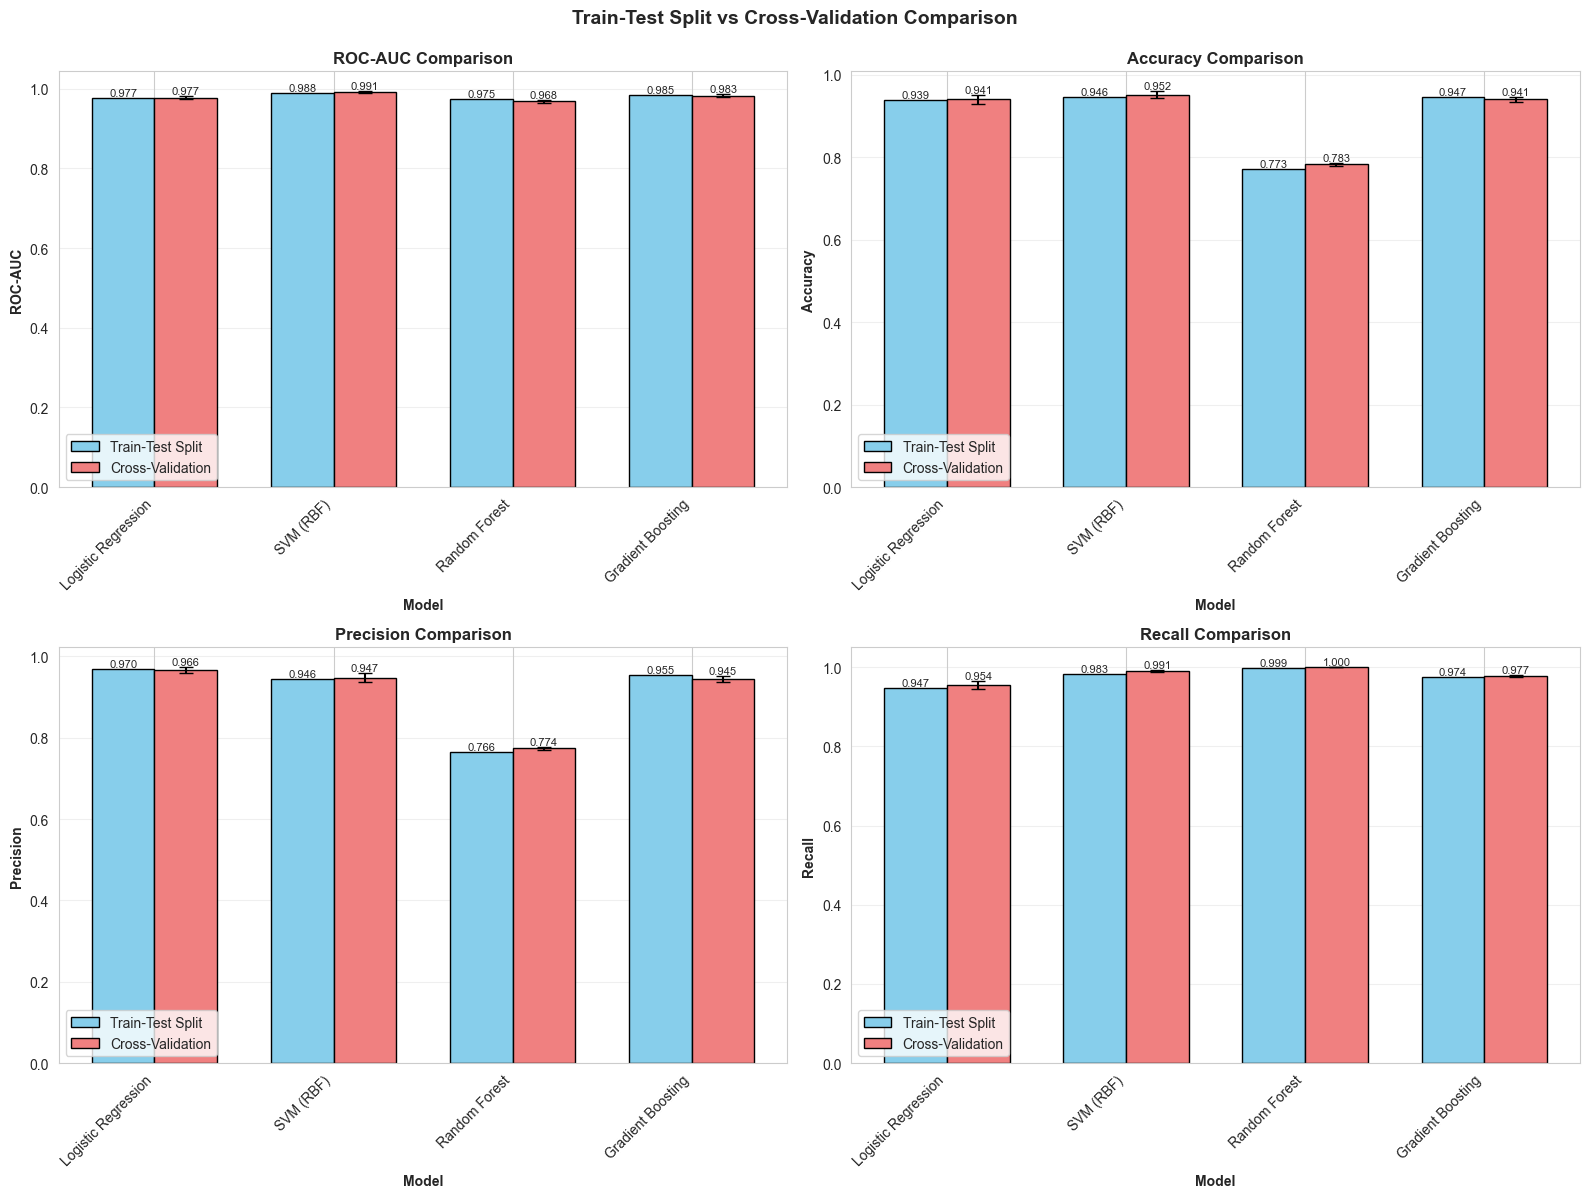

✓ Comparison plot saved to: reports/figures/model_comparison.png


In [10]:
# Compare Train-Test vs Cross-Validation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['roc_auc', 'accuracy', 'precision', 'recall']
metric_names = ['ROC-AUC', 'Accuracy', 'Precision', 'Recall']

for idx, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
    ax = axes[idx // 2, idx % 2]
    
    model_names = list(train_test_results.keys())
    
    # Train-test values
    tt_values = [train_test_results[name][metric] for name in model_names]
    
    # CV values
    cv_means = [cv_results[name][f'{metric}_mean'] for name in model_names]
    cv_stds = [cv_results[name][f'{metric}_std'] for name in model_names]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, tt_values, width, label='Train-Test Split', 
                   color='skyblue', edgecolor='black')
    bars2 = ax.bar(x + width/2, cv_means, width, yerr=cv_stds, 
                   label='Cross-Validation', color='lightcoral', 
                   edgecolor='black', capsize=5)
    
    ax.set_xlabel('Model', fontweight='bold')
    ax.set_ylabel(metric_name, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    for bar, std in zip(bars2, cv_stds):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + std,
               f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Train-Test Split vs Cross-Validation Comparison', 
            fontweight='bold', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'model_comparison.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved to: reports/figures/model_comparison.png")

---
## 6. ROC Curves

Visualize ROC curves for all models (Train-Test Split).


ROC CURVES


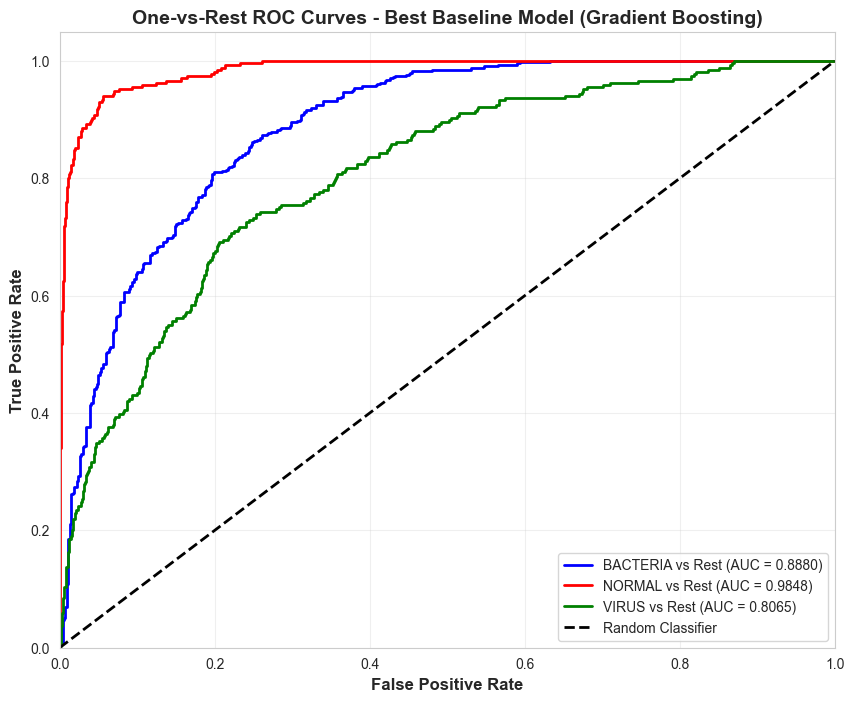

✓ Multiclass ROC curves saved to: reports/figures/roc_curves_ovr.png


In [15]:
print("\n" + "="*60)
print("ROC CURVES")
print("="*60)

if num_classes == 2:
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'orange']
    
    for (name, results), color in zip(train_test_results.items(), colors):
        y_score = results['y_pred_proba']
        if y_score.ndim == 2:
            y_score = y_score[:, 1]
        
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = results['roc_auc']
        
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC = {roc_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.5000)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
    plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
    plt.title('ROC Curves - Baseline Models (Train-Test Split)', fontweight='bold', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    
    plt.savefig(project_root / 'reports' / 'figures' / 'roc_curves.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ ROC curves saved to: reports/figures/roc_curves.png")

else:
    # Best model based on train-test ROC-AUC
    best_train_test_model = max(train_test_results.items(), key=lambda x: x[1]['roc_auc'])[0]
    best_results = train_test_results[best_train_test_model]
    
    y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
    y_score = best_results['y_pred_proba']
    
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        class_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, color=colors[i % len(colors)],
                 label=f'{class_name} vs Rest (AUC = {class_auc:.4f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
    plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
    plt.title(f'One-vs-Rest ROC Curves - Best Baseline Model ({best_train_test_model})',
              fontweight='bold', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    
    plt.savefig(project_root / 'reports' / 'figures' / 'roc_curves_ovr.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Multiclass ROC curves saved to: reports/figures/roc_curves_ovr.png")

---
## 7. Confusion Matrices

Visualize confusion matrices for all models.

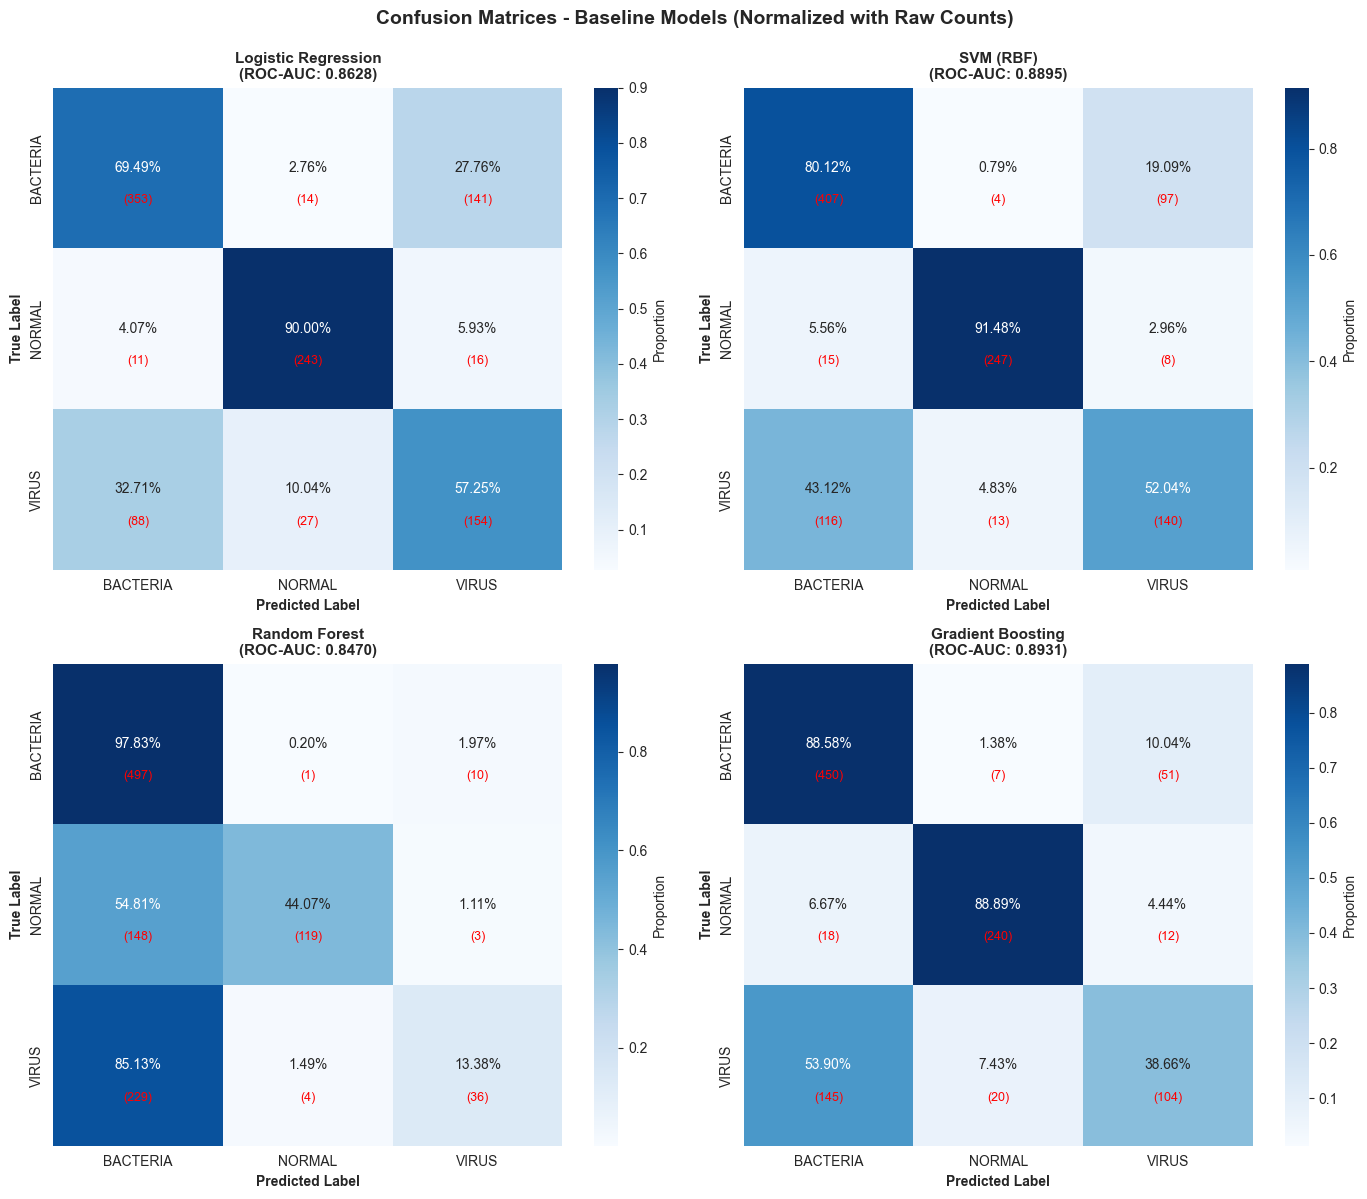

✓ Confusion matrices saved to: reports/figures/confusion_matrices.png


In [16]:
# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, results) in enumerate(train_test_results.items()):
    cm = results['confusion_matrix']
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_normalized = np.nan_to_num(cm_normalized)
    
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2%',
        cmap='Blues',
        ax=axes[idx],
        cbar_kws={'label': 'Proportion'},
        xticklabels=class_names,
        yticklabels=class_names
    )
    
    axes[idx].set_title(f'{name}\n(ROC-AUC: {results["roc_auc"]:.4f})',
                        fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('True Label', fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontweight='bold')
    
    # Add raw counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j + 0.5, i + 0.7, f'({cm[i, j]})',
                           ha='center', va='center', fontsize=9, color='red')

plt.suptitle('Confusion Matrices - Baseline Models (Normalized with Raw Counts)',
             fontweight='bold', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'confusion_matrices.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved to: reports/figures/confusion_matrices.png")

In [23]:
best_train_test_model_name = max(train_test_results.items(), key=lambda x: x[1]['roc_auc'])[0]
best_train_test_results = train_test_results[best_train_test_model_name]

print("\n" + "="*80)
print(f"CLASSIFICATION REPORT - BEST TRAIN-TEST MODEL ({best_train_test_model_name})")
print("="*80)

best_report_df = pd.DataFrame(best_train_test_results['classification_report']).T
display(best_report_df)


CLASSIFICATION REPORT - BEST TRAIN-TEST MODEL (Gradient Boosting)


,precision,recall,f1-score,support
BACTERIA,0.734095,0.885827,0.802855,508.000000
NORMAL,0.898876,0.888889,0.893855,270.000000
VIRUS,0.622754,0.386617,0.477064,269.000000
accuracy,0.758357,0.758357,0.758357,0.758357
macro avg,0.751909,0.720444,0.724591,1047.000000
weighted avg,0.747982,0.758357,0.742618,1047.000000


---
## 8. Feature Importance Analysis

Analyze feature importance for tree-based models.

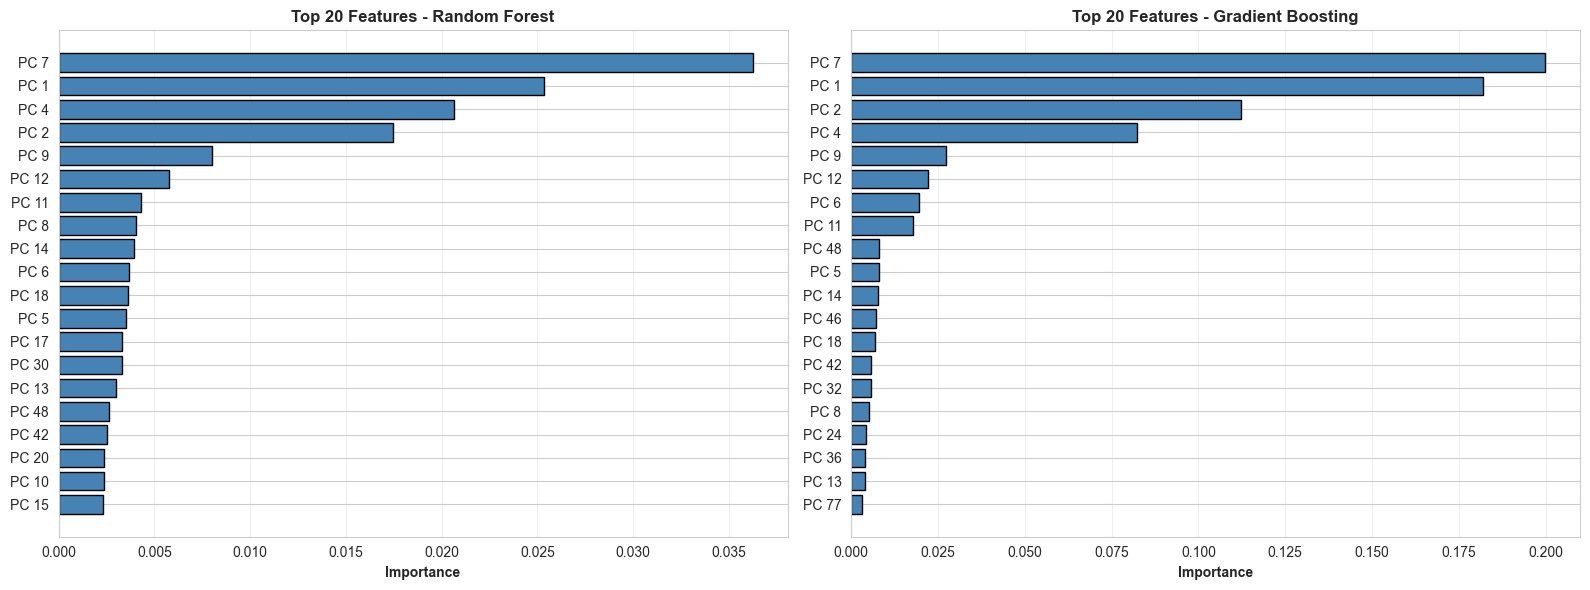

✓ Feature importance plot saved to: reports/figures/feature_importance.png


In [24]:
# Feature importance for tree-based models
tree_models = ['Random Forest', 'Gradient Boosting']
importances_dict = {}

for model_name in tree_models:
    if model_name in train_test_results:
        model = train_test_results[model_name]['trained_model']
        importances = model.feature_importances_
        importances_dict[model_name] = importances

if importances_dict:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, (name, importances) in enumerate(importances_dict.items()):
        # Get top 20 features
        top_n = 20
        top_indices = np.argsort(importances)[-top_n:][::-1]
        top_importances = importances[top_indices]
        
        axes[idx].barh(range(top_n), top_importances, color='steelblue', edgecolor='black')
        axes[idx].set_yticks(range(top_n))
        axes[idx].set_yticklabels([f'PC {i+1}' for i in top_indices])
        axes[idx].set_xlabel('Importance', fontweight='bold')
        axes[idx].set_title(f'Top {top_n} Features - {name}', fontweight='bold', fontsize=12)
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(project_root / 'reports' / 'figures' / 'feature_importance.png', 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Feature importance plot saved to: reports/figures/feature_importance.png")
else:
    print("⚠️  No tree-based models available for feature importance analysis.")

---
## 9. Model Selection & Saving

Select the best model based on ROC-AUC and save all trained models.

In [26]:
# Select best model based on CV ROC-AUC
best_model_name = max(cv_results.items(), key=lambda x: x[1]['roc_auc_mean'])[0]
best_model_score = cv_results[best_model_name]['roc_auc_mean']

print("\n" + "="*60)
print("BEST MODEL SELECTION")
print("="*60)
print(f"\nBest Model: {best_model_name}")
print(f"Cross-Validation ROC-AUC: {best_model_score:.4f} ± {cv_results[best_model_name]['roc_auc_std']:.4f}")
print(f"Train-Test ROC-AUC: {train_test_results[best_model_name]['roc_auc']:.4f}")

logger.info(f"Best model selected: {best_model_name} (ROC-AUC: {best_model_score:.4f})")


BEST MODEL SELECTION

Best Model: SVM (RBF)
Cross-Validation ROC-AUC: 0.8943 ± 0.0063
Train-Test ROC-AUC: 0.8895
[INFO] Best model selected: SVM (RBF) (ROC-AUC: 0.8943)


In [27]:
# Save all trained models
models_dir = project_root / 'models' / 'saved_models'
models_dir.mkdir(parents=True, exist_ok=True)

print("\nSaving trained models...")

for name, results in train_test_results.items():
    model = results['trained_model']
    
    # Create safe filename
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '').lower()
    model_path = models_dir / f'baseline_{safe_name}.pkl'
    
    # Save with metadata
    metadata = {
    'model_name': name,
    'model_type': type(model).__name__,
    'classification_mode': classification_mode,
    'class_names': class_names,
    'num_classes': num_classes,
    'train_test_roc_auc': float(results['roc_auc']),
    'train_test_f1': float(results['f1_score']),
    'train_test_precision': float(results['precision']),
    'train_test_recall': float(results['recall']),
    'cv_roc_auc_mean': float(cv_results[name]['roc_auc_mean']),
    'cv_roc_auc_std': float(cv_results[name]['roc_auc_std']),
    'cv_f1_mean': float(cv_results[name]['f1_mean']),
    'cv_f1_std': float(cv_results[name]['f1_std']),
    'training_samples': int(len(X_train)),
    'n_features': int(X_train.shape[1]),
    'is_best_model': name == best_model_name
}
    
    save_model(model, model_path, metadata=metadata)
    print(f"  ✓ Saved: {model_path.name}")

logger.info(f"All {len(train_test_results)} models saved")
print("\n✓ All models saved successfully")


Saving trained models...
✓ Model saved to c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\models\saved_models\baseline_logistic_regression.pkl
  ✓ Saved: baseline_logistic_regression.pkl
✓ Model saved to c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\models\saved_models\baseline_svm_rbf.pkl
  ✓ Saved: baseline_svm_rbf.pkl
✓ Model saved to c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\models\saved_models\baseline_random_forest.pkl
  ✓ Saved: baseline_random_forest.pkl
✓ Model saved to c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\models\saved_models\baseline_gradient_boosting.pkl
  ✓ Saved: baseline_gradient_boosting.pkl
[INFO] All 4 models saved

✓ All models saved successfully


In [28]:
# Save results summary
results_summary = {
    'classification_mode': classification_mode,
    'class_names': class_names,
    'num_classes': num_classes,
    'best_model': best_model_name,
    'best_model_cv_roc_auc': float(best_model_score),
    'train_test_results': {},
    'cv_results': {}
}

for name in train_test_results.keys():
    results_summary['train_test_results'][name] = {
        'roc_auc': float(train_test_results[name]['roc_auc']),
        'accuracy': float(train_test_results[name]['accuracy']),
        'precision': float(train_test_results[name]['precision']),
        'recall': float(train_test_results[name]['recall']),
        'f1_score': float(train_test_results[name]['f1_score']),
        'average_type': train_test_results[name]['average_type']
    }
    
    results_summary['cv_results'][name] = {
        'roc_auc_mean': float(cv_results[name]['roc_auc_mean']),
        'roc_auc_std': float(cv_results[name]['roc_auc_std']),
        'accuracy_mean': float(cv_results[name]['accuracy_mean']),
        'accuracy_std': float(cv_results[name]['accuracy_std']),
        'precision_mean': float(cv_results[name]['precision_mean']),
        'precision_std': float(cv_results[name]['precision_std']),
        'recall_mean': float(cv_results[name]['recall_mean']),
        'recall_std': float(cv_results[name]['recall_std']),
        'f1_mean': float(cv_results[name]['f1_mean']),
        'f1_std': float(cv_results[name]['f1_std'])
    }

summary_path = project_root / 'reports' / 'metrics' / 'baseline_results_summary.json'
summary_path.parent.mkdir(parents=True, exist_ok=True)

with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=4)

print(f"✓ Results summary saved to: {summary_path}")

✓ Results summary saved to: c:\Users\MOULOUDIA\OneDrive - Epitech\Bureau\epitech\T-DEV-810-PAR_19\reports\metrics\baseline_results_summary.json


## 10. Summary & Next Steps

### Completed:
- ✓ Loaded preprocessed PCA-transformed data
- ✓ Encoded multiclass labels consistently
- ✓ Implemented 4 baseline models
- ✓ Evaluated with train-test split (80/20)
- ✓ Evaluated with 5-fold cross-validation
- ✓ Compared both evaluation strategies
- ✓ Generated multiclass-aware ROC-AUC and confusion matrices
- ✓ Analyzed feature importance
- ✓ Selected best baseline model
- ✓ Saved all trained models

### Key Findings:
- **Best Model:** Selected based on cross-validation ROC-AUC
- **Classification Mode:** Multiclass
- **Detected Classes:** NORMAL, BACTERIA, VIRUS
- **Evaluation Strategy:** Cross-validation provides more robust estimates with confidence intervals
- **ROC-AUC:** Computed using a multiclass-aware one-vs-rest strategy
- **Class Imbalance:** Handled through class weighting in supported models

### Ready for Step 4: Deep Learning Implementation

In the next notebook (`04_Deep_Learning_CNN.ipynb`), we will:
1. Implement CNN architectures (custom + pre-trained)
2. Train deep learning models on real multiclass labels
3. Use Dataset3 for hyperparameter tuning
4. Compare deep learning vs baseline models
5. Evaluate multiclass performance consistently across the whole pipeline

---

**Key Files Generated:**
- `models/saved_models/baseline_*.pkl` - All trained models
- `models/saved_models/label_encoder.pkl` - Label encoder
- `reports/figures/model_comparison.png` - Train-test vs CV comparison
- `reports/figures/confusion_matrices.png` - Confusion matrices
- `reports/figures/feature_importance.png` - Feature importance
- `reports/metrics/baseline_results_summary.json` - Results summary
- `reports/pipeline.log` - Processing log

In [29]:
#verif 
print("\n" + "="*60)
print("FINAL BASELINE CHECK")
print("="*60)
print(f"Classification mode: {classification_mode}")
print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Best baseline model: {best_model_name}")
print(f"Best CV ROC-AUC: {best_model_score:.4f}")


FINAL BASELINE CHECK
Classification mode: multiclass
Classes: [np.str_('BACTERIA'), np.str_('NORMAL'), np.str_('VIRUS')]
Number of classes: 3
Best baseline model: SVM (RBF)
Best CV ROC-AUC: 0.8943
